# Part 4: Model Training and Evaluation
This notebook builds the machine learning models, benchmarks estimators, analyzes feature importances, and saves the production pipeline model.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, confusion_matrix, 
    classification_report, roc_auc_score, precision_score,
    recall_score,
    f1_score
)

df = pd.read_csv('../data/processed_telco_churn.csv')



# Train-Test Split 

In [13]:

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Buiild my baseline model(Logistic Regression)pipeline and compare it with other model pipeline

In [14]:

pipelines = {

    "Logistic Regression": Pipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),


    "Random Forest": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(random_state=42))
    ]),

   
    "Gradient Boosting": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "Support Vector Machine": Pipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(probability=True, random_state=42))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", KNeighborsClassifier())
    ]),


    "Gaussian Naive Bayes": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", GaussianNB())
    ]),

  
    "XGBoost": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ])

}


 # Stratified KFold

In [15]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

 # Cross Validate Every Model

In [16]:


results = []

for name, model in pipelines.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    results.append({

        "Model": name,

        "Accuracy":
            scores["test_accuracy"].mean(),

        "Precision":
            scores["test_precision"].mean(),

        "Recall":
            scores["test_recall"].mean(),

        "F1 Score":
            scores["test_f1"].mean(),

        "ROC AUC":
            scores["test_roc_auc"].mean()

    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)

print(results_df)

                    Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0     Logistic Regression  0.759145   0.531650  0.783278  0.633188  0.847433
4  Support Vector Machine  0.767306   0.546155  0.727090  0.623555  0.828855
3       Gradient Boosting  0.772989   0.559327  0.680268  0.613771  0.834553
6    Gaussian Naive Bayes  0.713171   0.476312  0.812040  0.600243  0.813697
2           Random Forest  0.779378   0.581945  0.598662  0.590030  0.820423
7                 XGBoost  0.771390   0.568302  0.577258  0.572621  0.811962
5     K-Nearest Neighbors  0.696485   0.455196  0.729766  0.560571  0.761131
1           Decision Tree  0.725950   0.485567  0.531104  0.507064  0.664163


# Hyperparameter Tuning

In [17]:
lr_pipeline = pipelines["Logistic Regression"]

param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"],
    "model__class_weight": [None, "balanced"]
}


grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid.best_score_)

# Best Pipeline
best_lr = grid.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

Best Cross-Validation F1 Score:
0.6348914050966231


# Predictions

In [18]:
y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]

In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7430801987224982
Precision: 0.5104166666666666
Recall : 0.786096256684492
F1 Score : 0.6189473684210526
ROC-AUC : 0.8444341109302747

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Confusion Matrix
[[753 282]
 [ 80 294]]


 # Baseline Model (Logistic Regression) Confusion Matrix

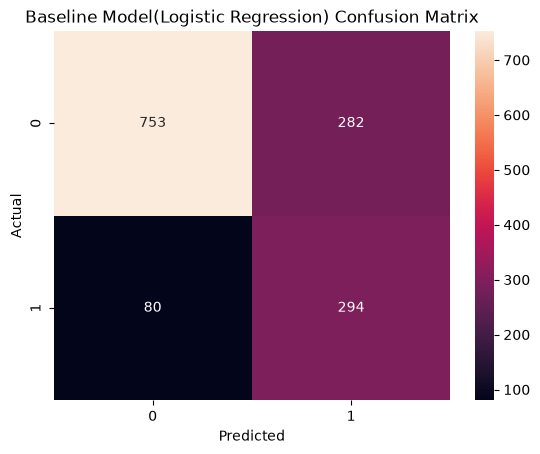

In [20]:
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr,annot=True,fmt='d')
plt.title('Baseline Model(Logistic Regression) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.savefig(
    "../plots/Model Evaluation/logistic regression confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Save the Production Model

In [21]:
joblib.dump(best_lr, '..\models\customer_churn_model.pkl')
print("Production model successfully saved to 'customer_churn_model.pkl'")

Production model successfully saved to 'customer_churn_model.pkl'
